# Technical Indicators — Feature Engineering Pipeline

**Goal:** Build a labeled dataset for training a model that predicts whether a 5-minute BTC candle on Polymarket closes **UP** or **DOWN**.

**What this notebook does:**
1. Loads legacy market data (869 candles, ~94K snapshots)
2. For each snapshot, computes 47 technical indicators using only data available *at that moment* (simulating real-time inference)
3. Outputs a flat JSONL file where each row = one snapshot + all indicators + the bet outcome

**Data source:** `data/legacy_candles.jsonl` — migrated from the legacy SQLite database. Each line is a completed 5-min candle with its per-second market snapshots nested inside.

**Key design choice:** Indicators are computed with a **rolling window** — at snapshot #5 in a candle, the indicators only see snapshots #0–#5. This simulates how the model would work in production, where future data is not available.

**Indicator categories:**

| Category | Count | Source data |
|----------|-------|-------------|
| BTC Cross-Candle (RSI, MACD, streaks, etc.) | 15 | Prior completed candles |
| BTC Intra-Candle (velocity, drawback, etc.) | 10 | Snapshots within current candle |
| Token Orderbook (imbalance, spread, R/R, etc.) | 13 | UP/DOWN orderbook per snapshot |
| Market Microstructure (correlation, liquidity, etc.) | 4 | Cross-domain combinations |
| Temporal (elapsed %, time-of-day, etc.) | 5 | Timestamps |
| Novel Composites (smart money, entropy, regime, etc.) | 7 | Multiple sources combined |

**Output:** `data/legacy_features.jsonl` — one JSON object per line, ready for model training.

In [15]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from technicals import compute_all
from tqdm import tqdm

## 1. Load and sort data

**What:** Read the migrated legacy data and sort candles chronologically.

**Why:** The indicator computation depends on temporal order — cross-candle indicators (RSI, streaks, MA crossovers) need to know which candles came *before* the current one. Sorting by `start_time` ensures we process them in the order they actually occurred.

**Result:** A list of candle dicts, each containing OHLC data, outcome (UP/DOWN), and nested snapshots (per-second market observations).

**How to read the output:** The print statement shows total candles and snapshots. Expect ~869 candles and ~94K snapshots. If either is 0, the data file is missing or corrupted.

In [16]:
DATA_PATH = Path("../data/legacy_candles.jsonl")
OUT_PATH = Path("../data/legacy_features.jsonl")

candles = []
with open(DATA_PATH) as f:
    for line in f:
        candles.append(json.loads(line))

candles.sort(key=lambda c: c["start_time"])
print(f"Loaded {len(candles)} candles, {sum(len(c['snapshots']) for c in candles):,} snapshots")

Loaded 869 candles, 94,336 snapshots


## 2. Compute indicators per snapshot

**What:** For every snapshot in every candle, compute all 49 technical indicators using `compute_all()` from `technicals.py`. Each snapshot produces one output row.

**Why:** This is the core feature engineering step. The function receives three pieces of state that simulate what a live trading system would know at that exact moment:
- `prior_candles` — all completed candles before this one (for RSI, streaks, MA, Bollinger, etc.)
- `candle_open` — the current candle's BTC open price (for "move from open" calculations)
- `snapshots_so_far` — snapshots #0 through #N in the current candle (for velocity, imbalance trends, etc.)

**Key detail:** The inner loop builds `snapshots_so_far` incrementally — at snapshot #0 it's a list of 1, at snapshot #10 it's a list of 11. This is what makes the computation realistic: early snapshots have fewer data points, so some indicators return `None` (not enough history yet).

**Result:** A list of flat dicts — each row has 13 snapshot fields + 49 indicator values + 1 outcome label.

**How to read the output:** The progress bar shows candles processed. The final print shows total rows. Expect ~94K rows. Runtime is ~30 seconds because the rolling window computation is O(n^2) per candle (each snapshot recomputes from scratch).

In [17]:
rows = []
prior_candles = []

for candle in tqdm(candles, desc="Candles"):
    snapshots = candle["snapshots"]
    outcome = candle["outcome"]
    candle_open = candle["open"]

    for si in range(len(snapshots)):
        snapshots_so_far = snapshots[: si + 1]
        indicators = compute_all(prior_candles, candle_open, snapshots_so_far)

        # Snapshot fields (drop nested lists to keep rows flat)
        snap = snapshots[si]
        row = {
            "candle_id": candle["candle_id"],
            "timestamp": snap["timestamp"],
            "elapsed_pct": snap["elapsed_pct"],
            "btc_price": snap["btc_price"],
            "up_best_bid": snap["up_bids"][0][0] if snap["up_bids"] else None,
            "up_best_ask": snap["up_asks"][0][0] if snap["up_asks"] else None,
            "up_bid_depth": snap["up_bids"][0][1] if snap["up_bids"] else None,
            "up_ask_depth": snap["up_asks"][0][1] if snap["up_asks"] else None,
            "down_best_bid": snap["down_bids"][0][0] if snap["down_bids"] else None,
            "down_best_ask": snap["down_asks"][0][0] if snap["down_asks"] else None,
            "down_bid_depth": snap["down_bids"][0][1] if snap["down_bids"] else None,
            "down_ask_depth": snap["down_asks"][0][1] if snap["down_asks"] else None,
            "market_volume": snap["market_volume"],
            **indicators,
            "outcome": outcome,
        }
        rows.append(row)

    # This candle is now "prior" for next ones
    prior_candles.append(candle)

print(f"\nDone: {len(rows):,} rows from {len(candles)} candles")

Candles: 100%|██████████| 869/869 [00:27<00:00, 31.09it/s]


Done: 94,336 rows from 869 candles


## 3. Drop unreliable indicators

**What:** Remove indicators whose computation depends on data fields that are degraded in the legacy dataset.

**Why:** The legacy SQLite database did not record real intra-candle high/low prices — it only stored `btc_open` and `btc_close`. During migration, we approximated `high = max(open, close)` and `low = min(open, close)`. This is a lossy approximation: in reality, BTC could spike $200 above the open mid-candle and still close near the open. Two indicators rely on accurate high/low:

- **`stochastic_k`** — measures where the close sits within the N-candle high-low range. With fake high/low, this range is artificially compressed, making the indicator meaningless.
- **`adx`** — computes True Range as `max(H-L, |H-prevC|, |L-prevC|)`. With H=L=max(O,C), the True Range is always just `|close - prev_close|`, which is a different (weaker) signal.

**Result:** 2 columns removed from every row, leaving 47 clean indicators.

**Note:** All other indicators use data that is genuinely available in the legacy set — BTC price ticks, orderbook best bid/ask + depth, and candle open/close. The `market_volume` field in snapshots is the sum of orderbook depths (not trade volume), which is real data and accurately represents what it measures.

In [18]:
DEGRADED_INDICATORS = [
    "stochastic_k",  # high/low = max/min(open,close), not real intra-candle extremes
    "adx",  # True Range needs real high/low
]

for row in rows:
    for key in DEGRADED_INDICATORS:
        row.pop(key, None)

print(f"Dropped {len(DEGRADED_INDICATORS)} unreliable indicators: {DEGRADED_INDICATORS}")
print(
    f"Remaining indicator count: {sum(1 for k in rows[0] if k not in ('candle_id', 'timestamp', 'elapsed_pct', 'btc_price', 'up_best_bid', 'up_best_ask', 'up_bid_depth', 'up_ask_depth', 'down_best_bid', 'down_best_ask', 'down_bid_depth', 'down_ask_depth', 'market_volume', 'outcome'))}"
)

Dropped 2 unreliable indicators: ['stochastic_k', 'adx']
Remaining indicator count: 52


## 4. Write output JSONL

**What:** Serialize all rows to `data/legacy_features.jsonl` — one JSON object per line.

**Why:** JSONL is the standard format for ML dataset pipelines. Each line is self-contained (no schema dependency), easy to stream, and directly loadable by libraries like HuggingFace `datasets`, pandas (`pd.read_json(..., lines=True)`), or plain Python.

**Result:** A single file where each line looks like:
```json
{"candle_id": "btc-updown-5m-...", "btc_price": 66092.75, ..., "rsi": 54.3, "btc_velocity": 12.5, ..., "outcome": "UP"}
```

**How to read the output:** Check the file size (expect ~220 MB for ~94K rows x 47 indicators). The row count should match step 2.

## 5. Coverage and quality check

**What:** For each indicator, count how many rows have a non-null value. Also check the UP/DOWN balance.

**Why:** Some indicators return `None` when there isn't enough data to compute them — for example, RSI needs 15 prior candles, so the first 14 candles' snapshots will have `rsi=None`. Hurst exponent needs 20 snapshots within the current candle, so the first 19 snapshots of each candle will have `hurst_exponent=None`. This is expected and correct — it reflects what a live system would actually know.

**How to interpret the coverage table:**
- **100%** = always computable (e.g. `btc_move_from_open` — just needs the current snapshot)
- **95-99%** = needs a few prior candles or snapshots (e.g. `rsi` needs 15 candles, so ~2% of rows at the start are null)
- **82-90%** = needs substantial history (e.g. `hurst_exponent` needs 20 snapshots, so the first ~20 snapshots of every candle are null)
- **Below 80%** would be a red flag — means the indicator is rarely computable

**How to interpret the outcome distribution:**
- Should be roughly 50/50 (UP vs DOWN). If heavily skewed, the model might learn to always predict the majority class.
- The sample row lets you visually inspect one complete feature vector to verify the schema looks correct.

In [19]:
# Check how many rows have non-null values per indicator
indicator_keys = [
    k
    for k in rows[0]
    if k
    not in (
        "candle_id",
        "timestamp",
        "elapsed_pct",
        "btc_price",
        "up_best_bid",
        "up_best_ask",
        "up_bid_depth",
        "up_ask_depth",
        "down_best_bid",
        "down_best_ask",
        "down_bid_depth",
        "down_ask_depth",
        "market_volume",
        "outcome",
    )
]

print(f"{'Indicator':<30} {'Non-null':>8} {'Coverage':>8}")
print("-" * 50)
for key in indicator_keys:
    non_null = sum(1 for r in rows if r[key] is not None)
    pct = non_null / len(rows) * 100
    print(f"{key:<30} {non_null:>8,} {pct:>7.1f}%")

Indicator                      Non-null Coverage
--------------------------------------------------
prior_return                     94,306   100.0%
consecutive_streak               94,306   100.0%
streak_magnitude                 94,306   100.0%
rolling_volatility               93,783    99.4%
candle_momentum                  93,783    99.4%
ma_crossover                     93,155    98.7%
trend_consistency                93,260    98.9%
reversal_regime                  93,993    99.6%
rsi                              92,849    98.4%
bollinger_pct_b                  92,329    97.9%
return_autocorrelation           92,227    97.8%
multi_candle_return_3            94,099    99.7%
multi_candle_return_6            93,783    99.4%
btc_move_from_open               94,336   100.0%
btc_velocity                     92,486    98.0%
intra_candle_volatility          90,860    96.3%
peak_drawback                    90,860    96.3%
btc_acceleration                 89,991    95.4%
btc_direction_cons

In [20]:
# Outcome distribution in output
up = sum(1 for r in rows if r["outcome"] == "UP")
dn = len(rows) - up
print(f"UP snapshots: {up:,} ({up / len(rows) * 100:.1f}%)")
print(f"DOWN snapshots: {dn:,} ({dn / len(rows) * 100:.1f}%)")

UP snapshots: 45,933 (48.7%)
DOWN snapshots: 48,403 (51.3%)


In [21]:
# Sample output row
rows[5000]

{'candle_id': 'btc-updown-5m-1772054700',
 'timestamp': 1772054904.876433,
 'elapsed_pct': 0.677315,
 'btc_price': 68936.92,
 'up_best_bid': 0.04,
 'up_best_ask': 0.05,
 'up_bid_depth': 278.3566,
 'up_ask_depth': 25554.171000000002,
 'down_best_bid': 0.95,
 'down_best_ask': 0.96,
 'down_bid_depth': 9357.209,
 'down_ask_depth': 18699.9834,
 'market_volume': 53889.72,
 'prior_return': 0.00041669738148105497,
 'consecutive_streak': 1,
 'streak_magnitude': 28.75,
 'rolling_volatility': 67.45666666666996,
 'candle_momentum': 0.3333333333333333,
 'ma_crossover': -32.06549999999697,
 'trend_consistency': 0.2,
 'reversal_regime': 0.6666666666666666,
 'rsi': 64.51726085542629,
 'bollinger_pct_b': 0.49197220027012944,
 'return_autocorrelation': -0.0960463436277954,
 'multi_candle_return_3': -0.0020736090254439275,
 'multi_candle_return_6': -0.001669969057075168,
 'btc_move_from_open': -81.54000000000815,
 'btc_velocity': -81.73405416615306,
 'intra_candle_volatility': 0.00011482646601583522,
 'p

## 6. Indicator distributions

**What:** For each indicator, plot overlapping histograms of its values split by outcome (green = UP, red = DOWN).

**Why:** This is the most intuitive way to see if an indicator carries predictive signal. If the green and red distributions are in the same place, the indicator doesn't help distinguish UP from DOWN. If they're shifted apart, it does.

**How to read each chart:**
- **X-axis** = indicator value
- **Y-axis** = density (normalized so area under each curve = 1, allowing fair comparison even with different sample sizes)
- **Green (UP)** = distribution of this indicator when the candle ended UP
- **Red (DOWN)** = distribution when the candle ended DOWN
- **Good signal** = the green and red peaks are visibly separated (e.g. `btc_move_from_open` should have green shifted right, red shifted left)
- **No signal** = the two histograms overlap almost completely (e.g. `price_path_entropy` may look like one blob)
- **Unexpected shape** = if a distribution is heavily skewed or has spikes, the indicator may need normalization before feeding to a model

Plotting:   0%|          | 0/52 [00:00<?, ?it/s]

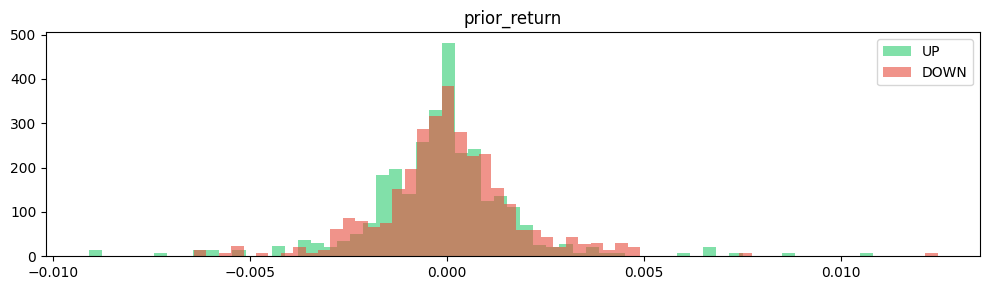

Plotting:   2%|▏         | 1/52 [00:00<00:06,  7.70it/s]

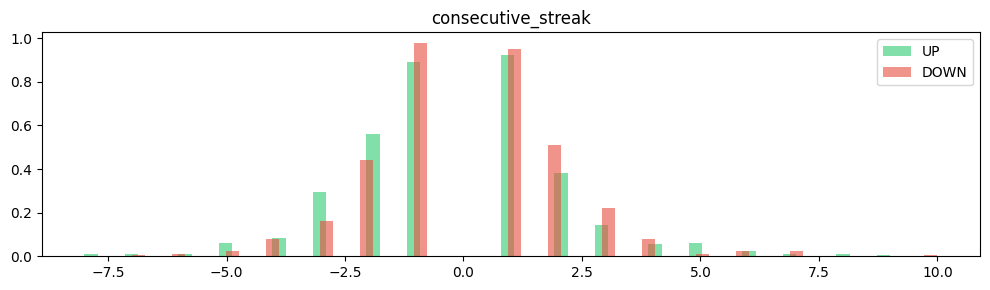

Plotting:   4%|▍         | 2/52 [00:00<00:06,  7.75it/s]

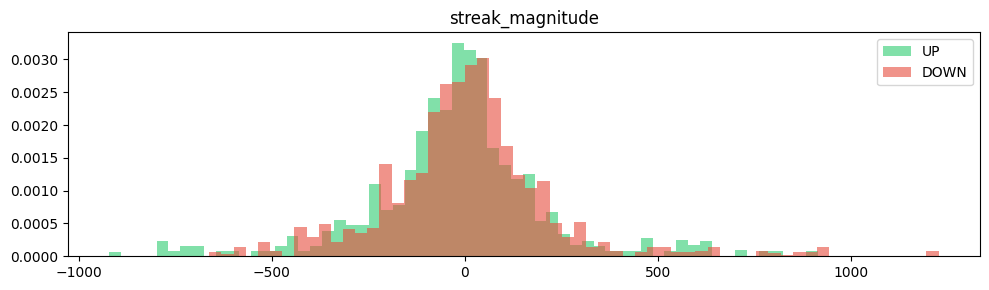

Plotting:   6%|▌         | 3/52 [00:00<00:06,  7.50it/s]

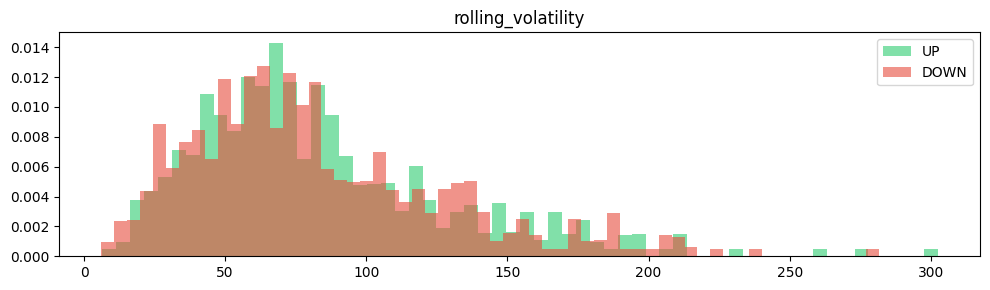

Plotting:   8%|▊         | 4/52 [00:00<00:06,  7.33it/s]

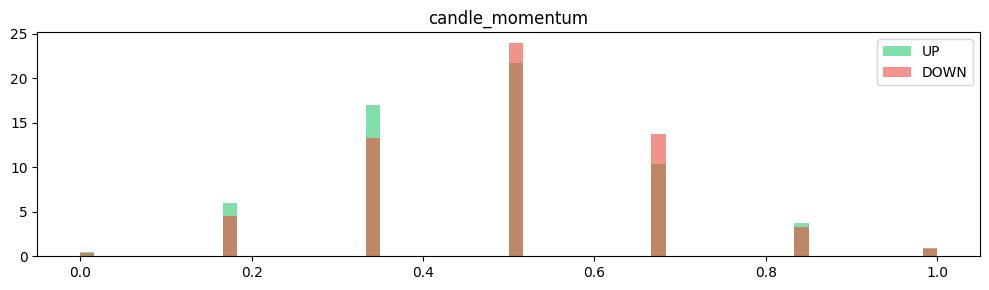

Plotting:  10%|▉         | 5/52 [00:00<00:06,  7.31it/s]

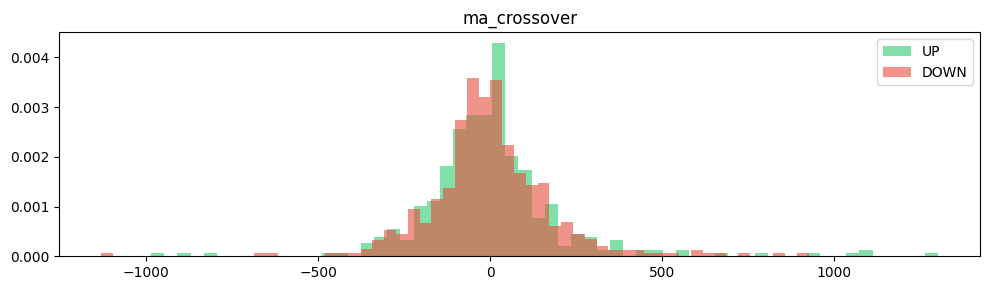

Plotting:  12%|█▏        | 6/52 [00:00<00:06,  7.37it/s]

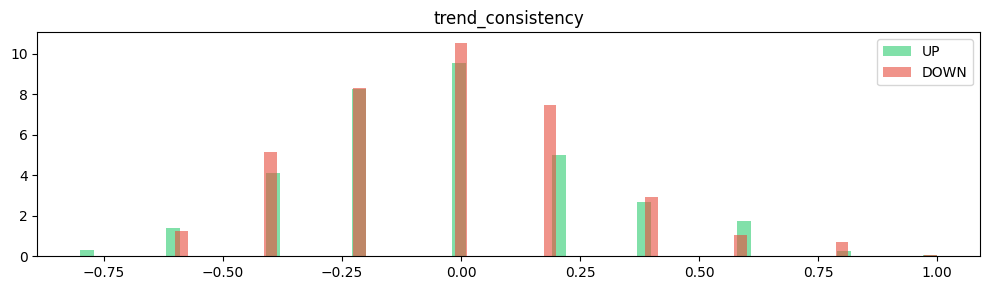

Plotting:  13%|█▎        | 7/52 [00:00<00:06,  6.87it/s]

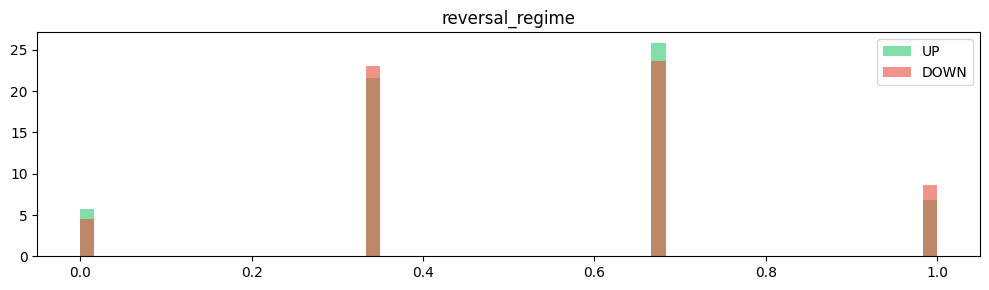

Plotting:  15%|█▌        | 8/52 [00:01<00:06,  7.00it/s]

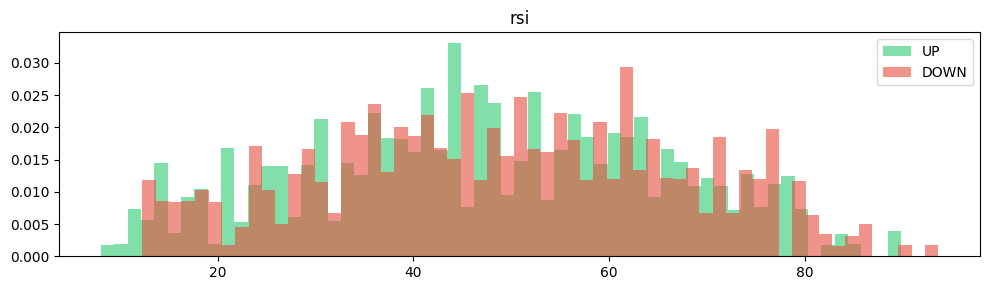

Plotting:  17%|█▋        | 9/52 [00:01<00:06,  7.00it/s]

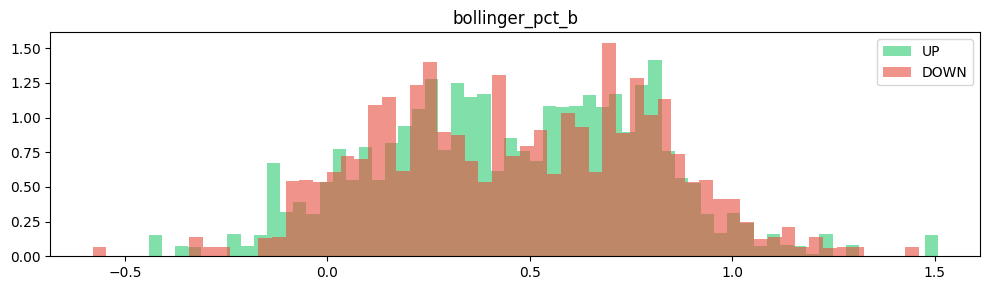

Plotting:  19%|█▉        | 10/52 [00:01<00:05,  7.03it/s]

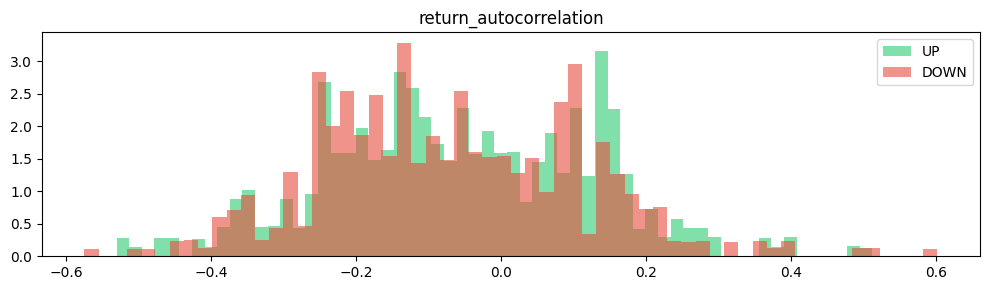

Plotting:  21%|██        | 11/52 [00:01<00:05,  7.13it/s]

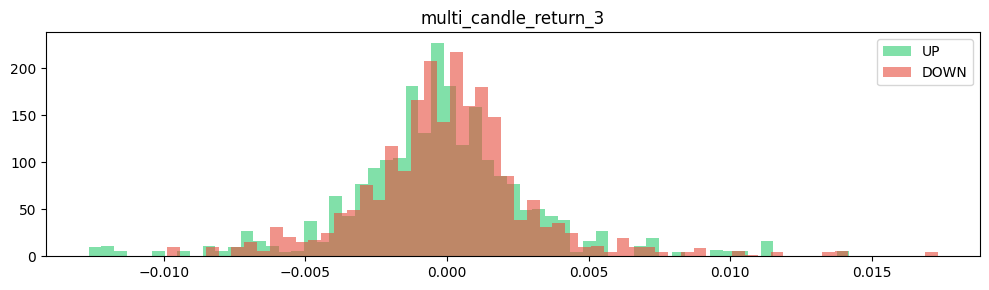

Plotting:  23%|██▎       | 12/52 [00:01<00:05,  7.22it/s]

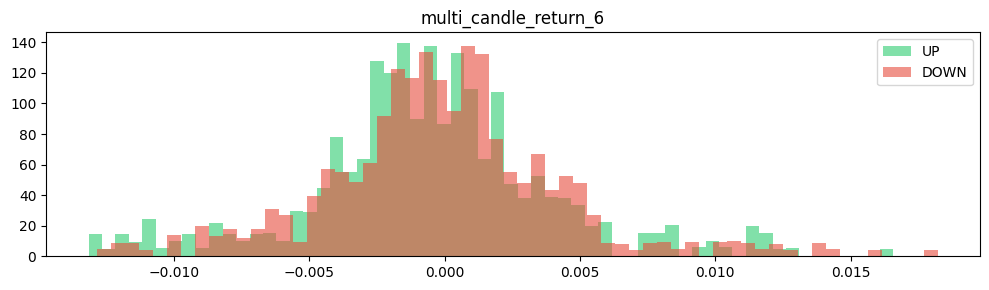

Plotting:  25%|██▌       | 13/52 [00:01<00:05,  7.03it/s]

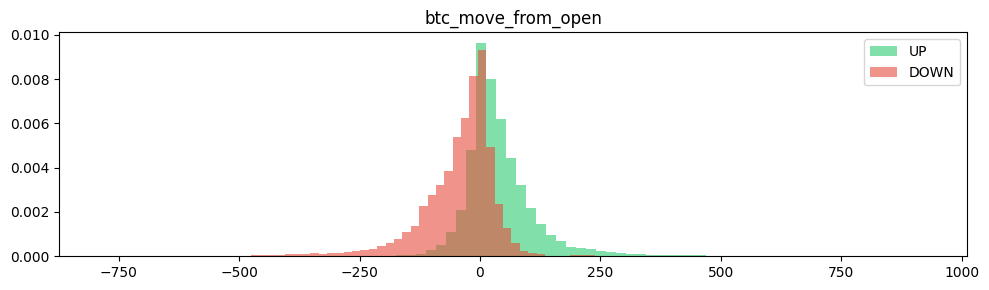

Plotting:  27%|██▋       | 14/52 [00:01<00:05,  6.99it/s]

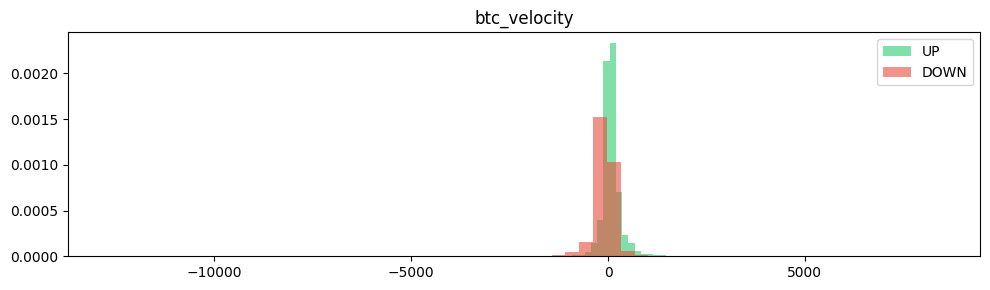

Plotting:  29%|██▉       | 15/52 [00:02<00:05,  6.90it/s]

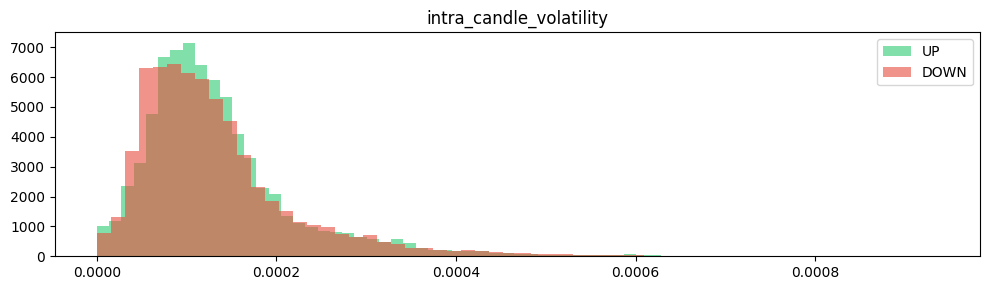

Plotting:  31%|███       | 16/52 [00:02<00:05,  7.01it/s]

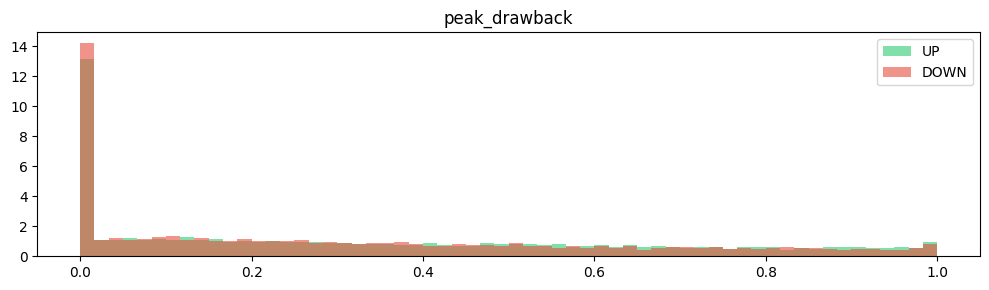

Plotting:  33%|███▎      | 17/52 [00:02<00:04,  7.01it/s]

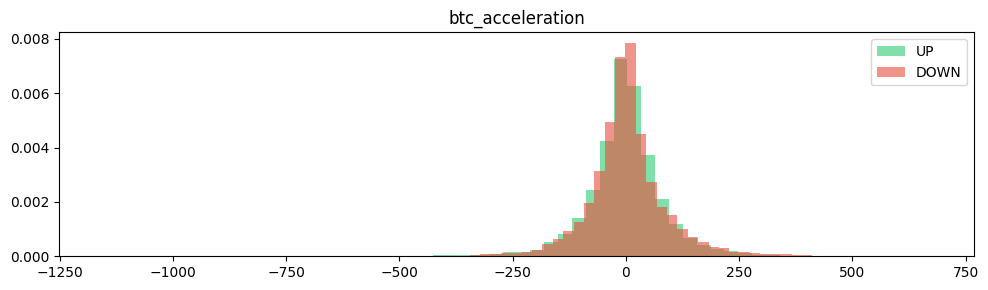

Plotting:  35%|███▍      | 18/52 [00:02<00:04,  6.94it/s]

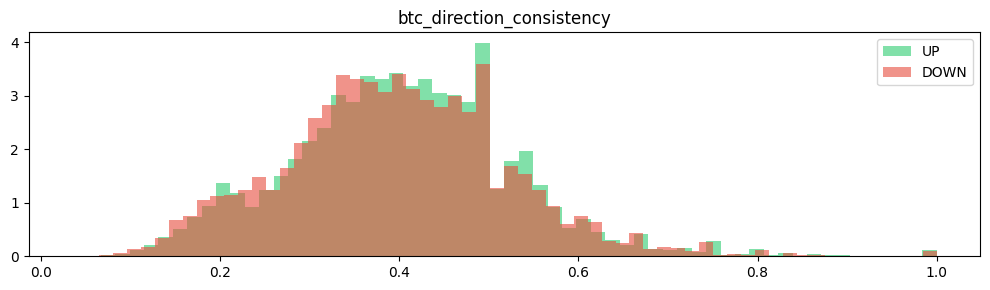

Plotting:  37%|███▋      | 19/52 [00:02<00:04,  6.97it/s]

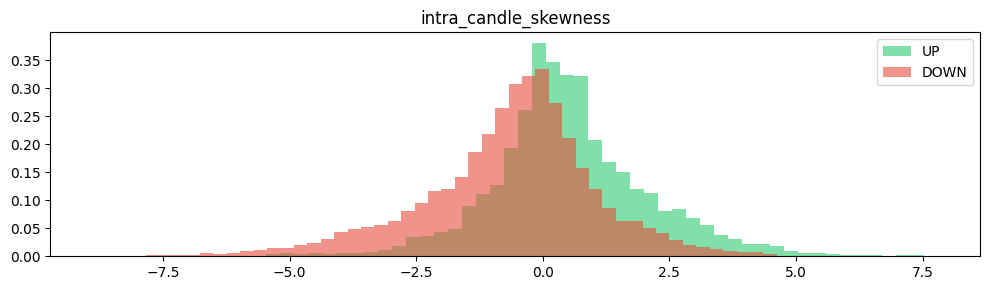

Plotting:  38%|███▊      | 20/52 [00:02<00:04,  7.05it/s]

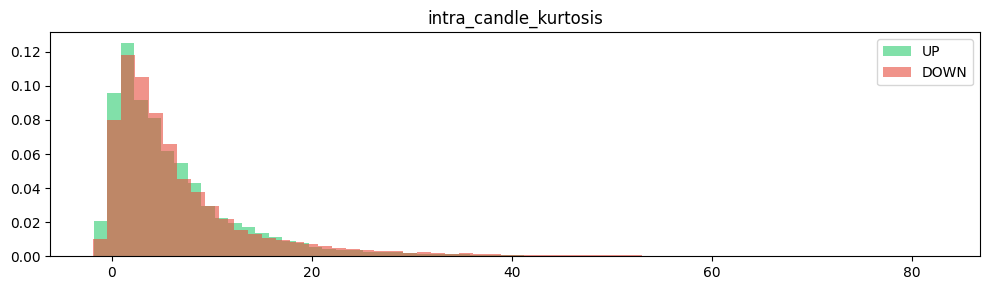

Plotting:  40%|████      | 21/52 [00:02<00:04,  7.20it/s]

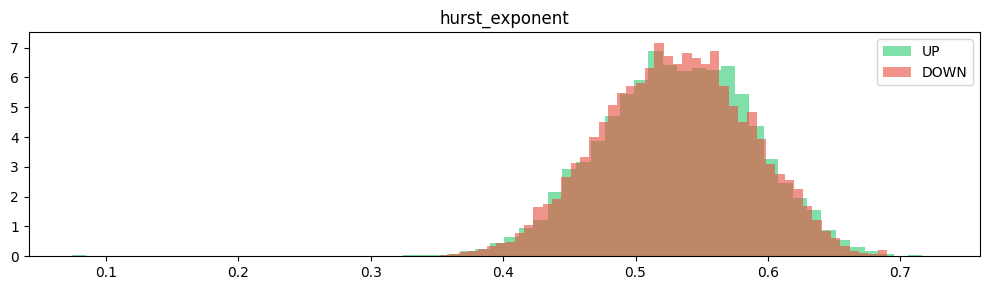

Plotting:  42%|████▏     | 22/52 [00:03<00:04,  7.38it/s]

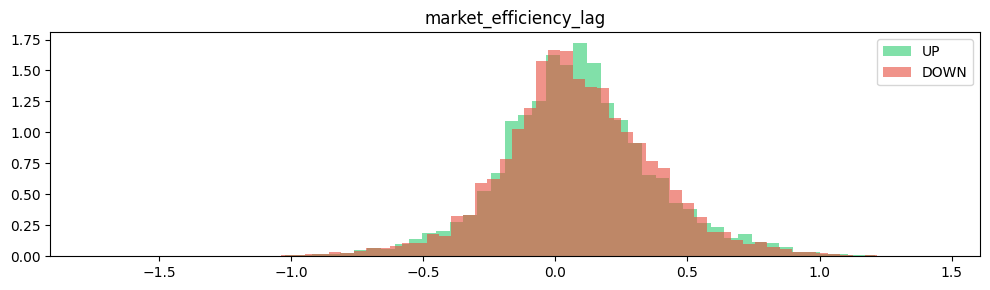

Plotting:  44%|████▍     | 23/52 [00:03<00:03,  7.41it/s]

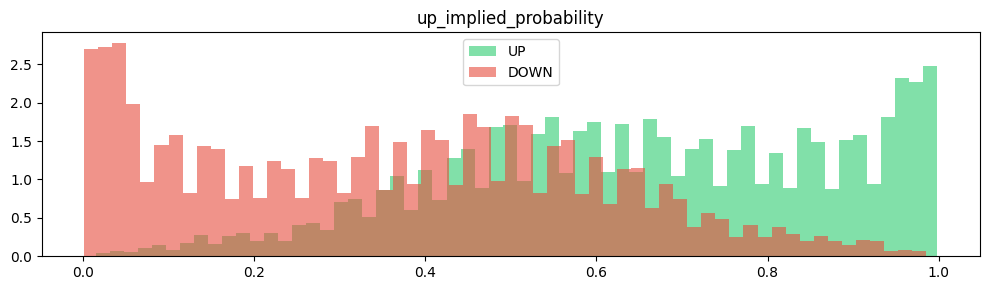

Plotting:  46%|████▌     | 24/52 [00:03<00:03,  7.45it/s]

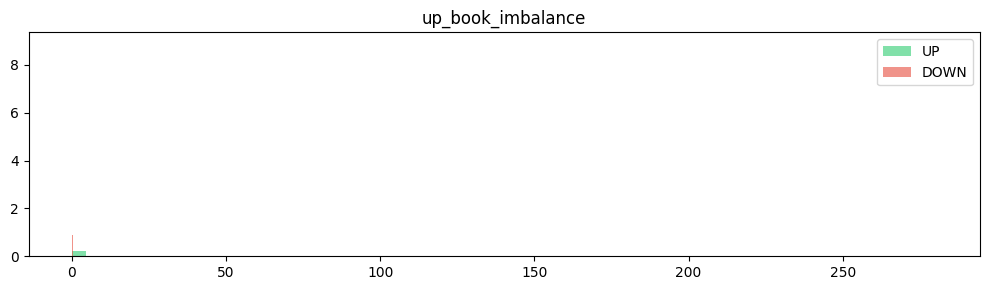

Plotting:  48%|████▊     | 25/52 [00:03<00:03,  7.41it/s]

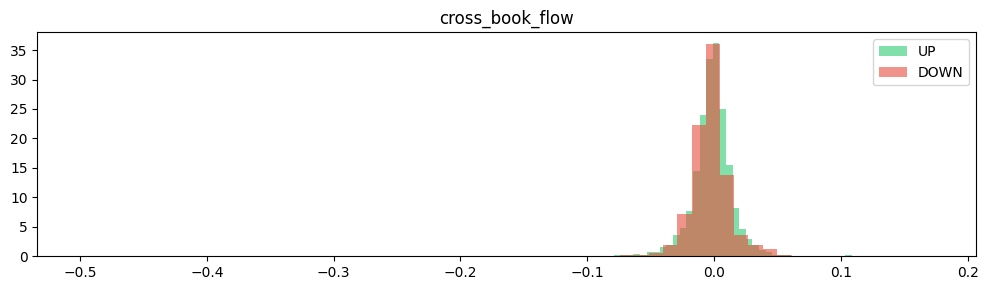

Plotting:  50%|█████     | 26/52 [00:03<00:03,  7.26it/s]

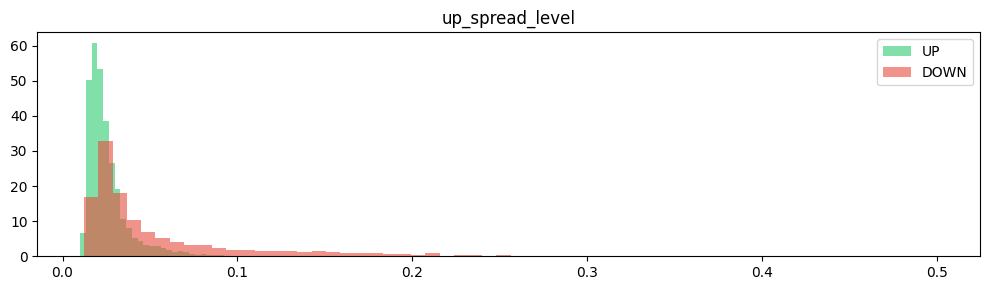

Plotting:  52%|█████▏    | 27/52 [00:03<00:03,  7.28it/s]

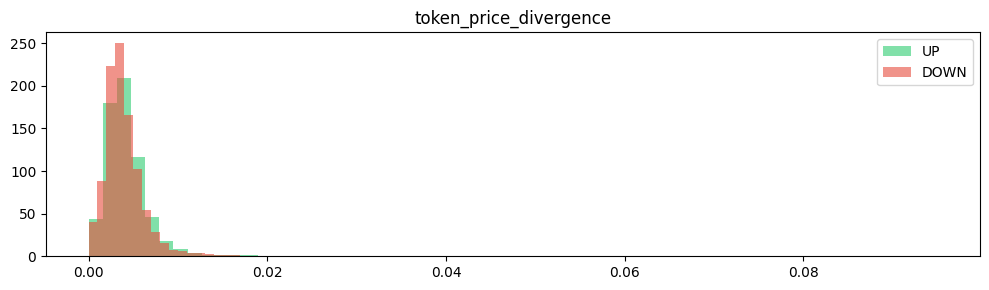

Plotting:  54%|█████▍    | 28/52 [00:03<00:03,  7.25it/s]

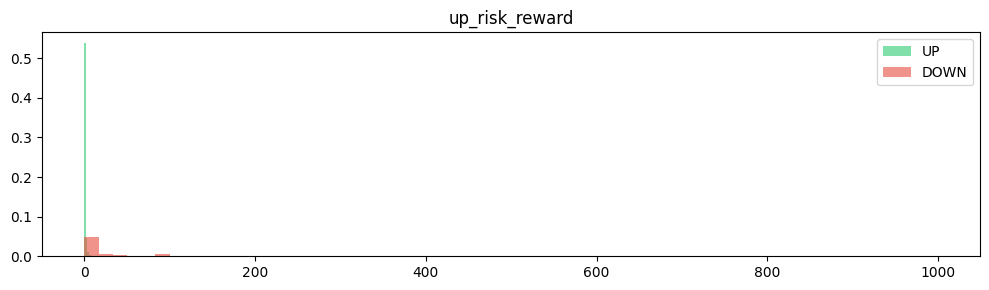

Plotting:  56%|█████▌    | 29/52 [00:04<00:03,  7.32it/s]

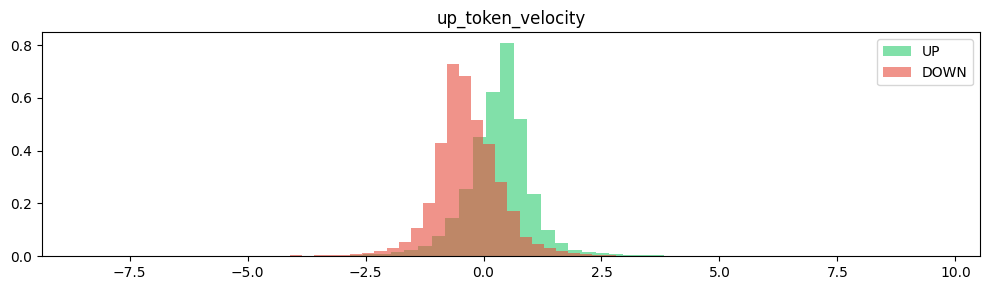

Plotting:  58%|█████▊    | 30/52 [00:04<00:03,  7.33it/s]

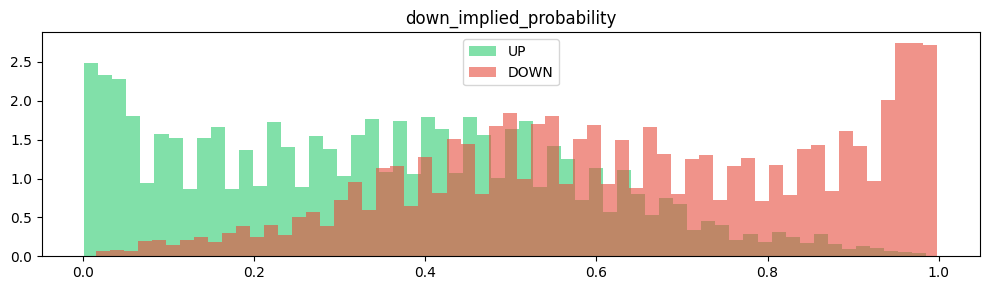

Plotting:  60%|█████▉    | 31/52 [00:04<00:02,  7.39it/s]

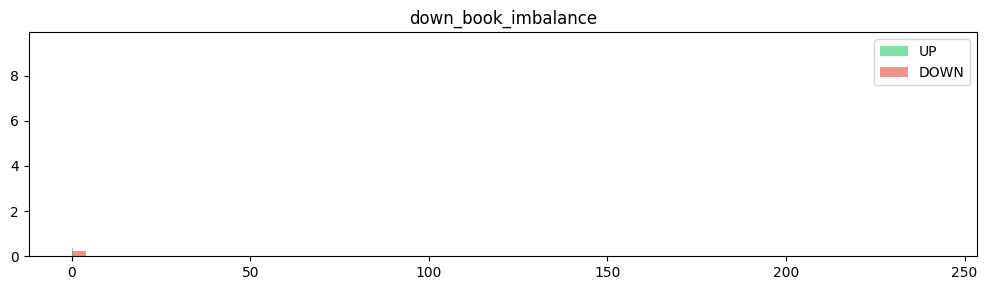

Plotting:  62%|██████▏   | 32/52 [00:04<00:02,  7.34it/s]

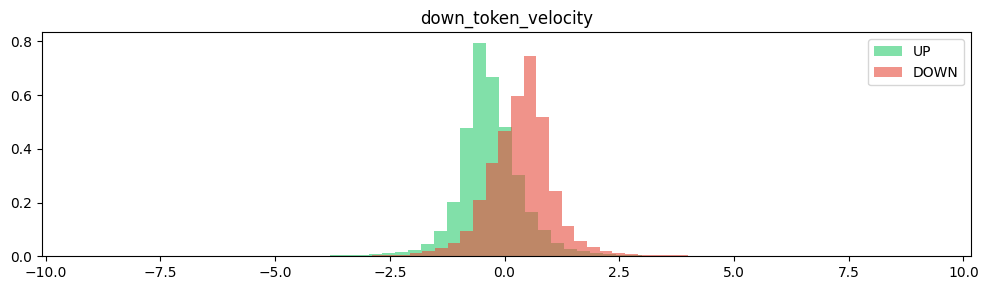

Plotting:  63%|██████▎   | 33/52 [00:04<00:02,  6.68it/s]

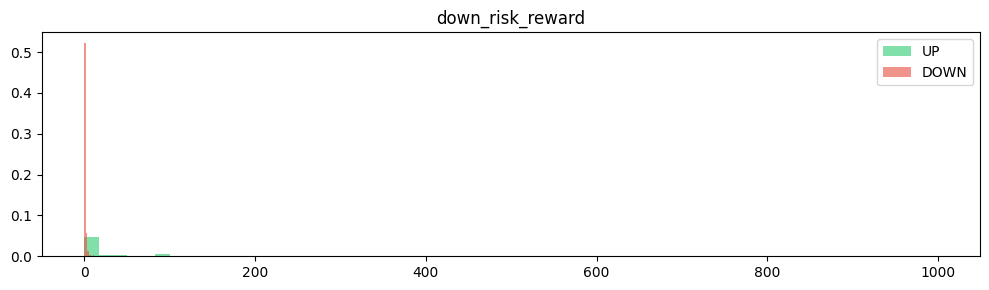

Plotting:  65%|██████▌   | 34/52 [00:04<00:02,  6.71it/s]

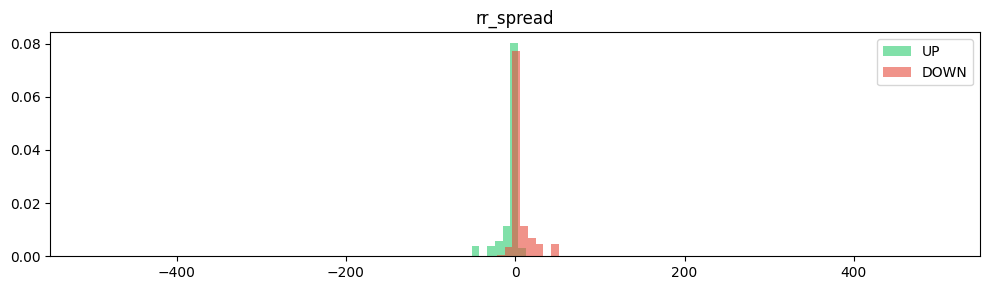

Plotting:  67%|██████▋   | 35/52 [00:04<00:02,  6.91it/s]

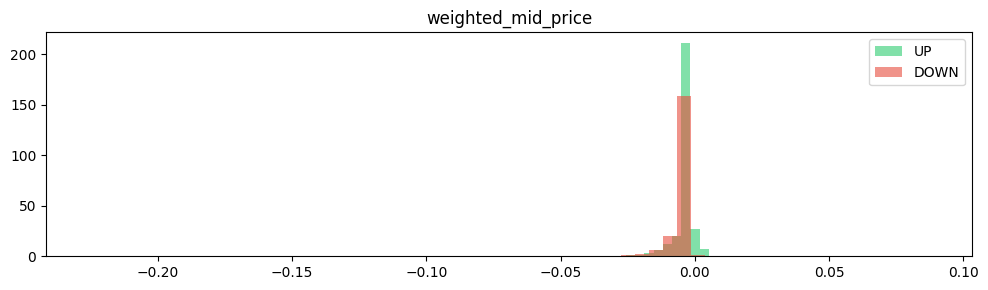

Plotting:  69%|██████▉   | 36/52 [00:05<00:02,  6.65it/s]

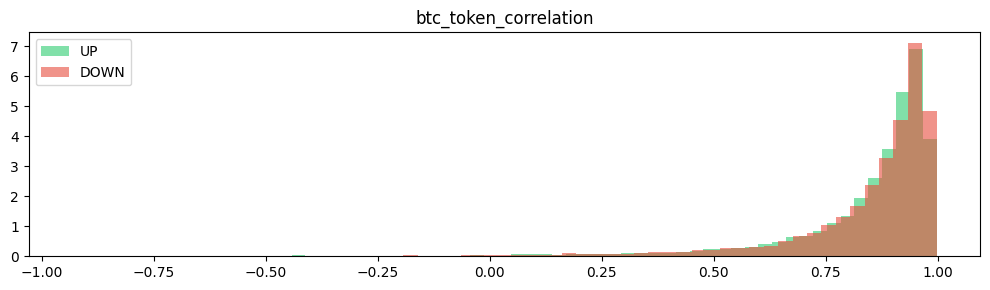

Plotting:  71%|███████   | 37/52 [00:05<00:02,  6.52it/s]

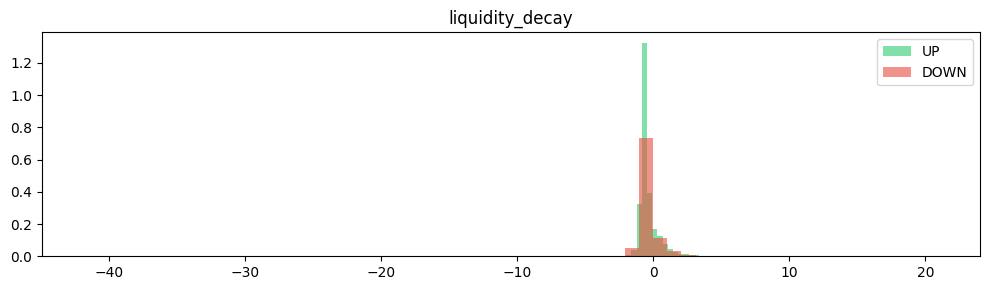

Plotting:  73%|███████▎  | 38/52 [00:05<00:02,  6.51it/s]

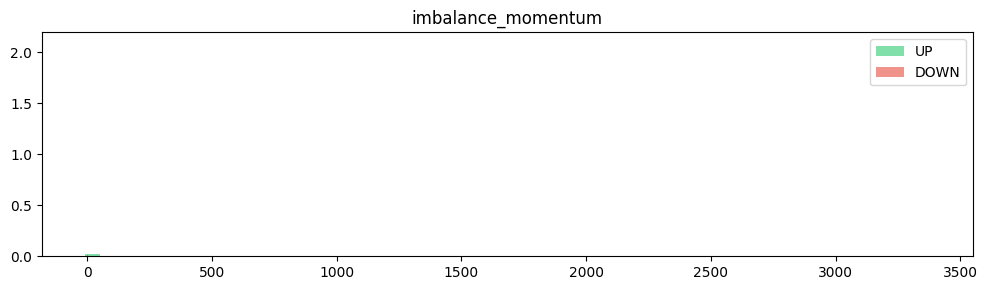

Plotting:  75%|███████▌  | 39/52 [00:05<00:01,  6.70it/s]

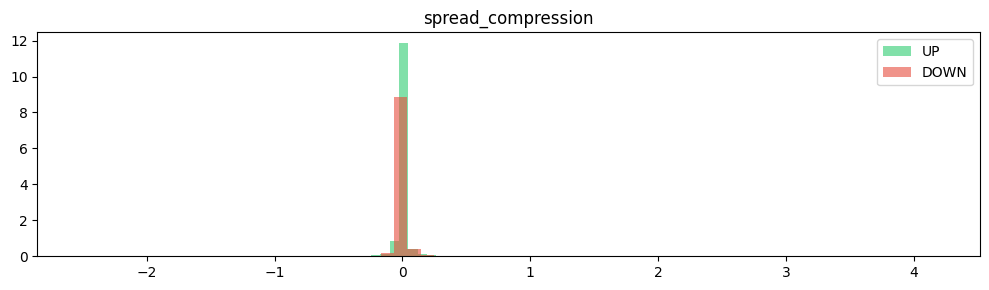

Plotting:  77%|███████▋  | 40/52 [00:05<00:01,  6.88it/s]

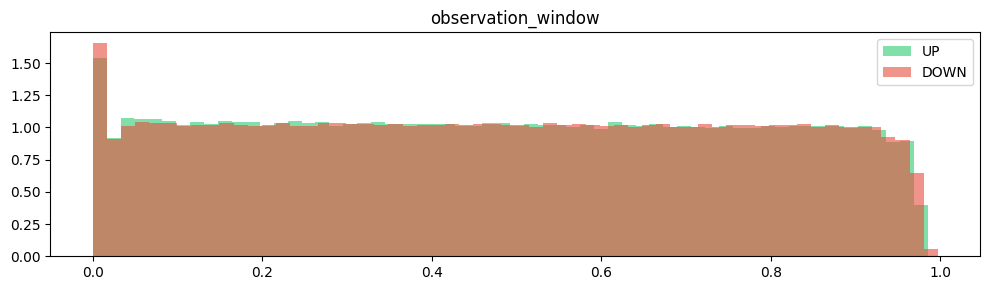

Plotting:  79%|███████▉  | 41/52 [00:05<00:01,  6.93it/s]

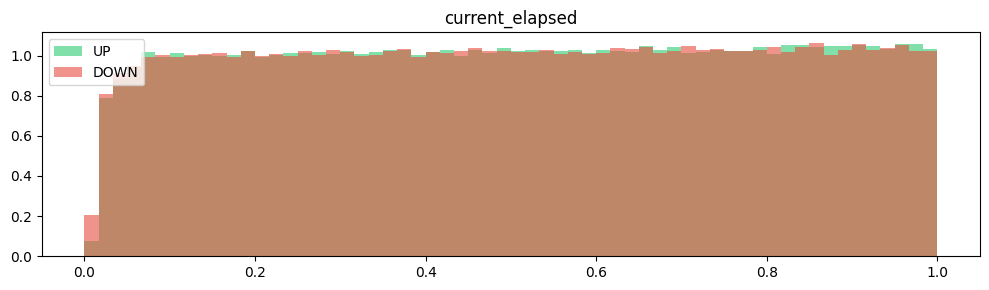

Plotting:  81%|████████  | 42/52 [00:05<00:01,  7.01it/s]

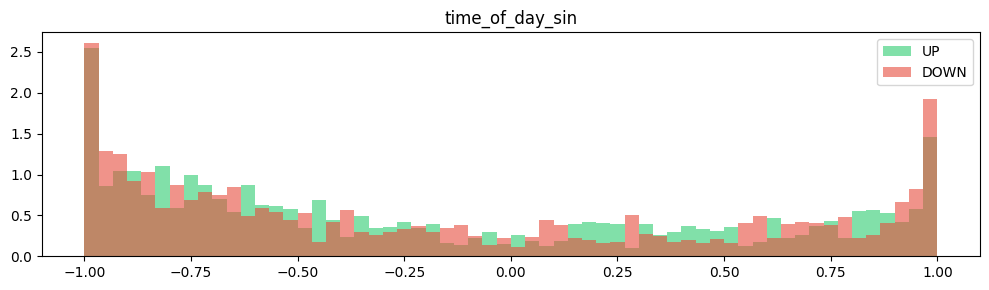

Plotting:  83%|████████▎ | 43/52 [00:06<00:01,  6.80it/s]

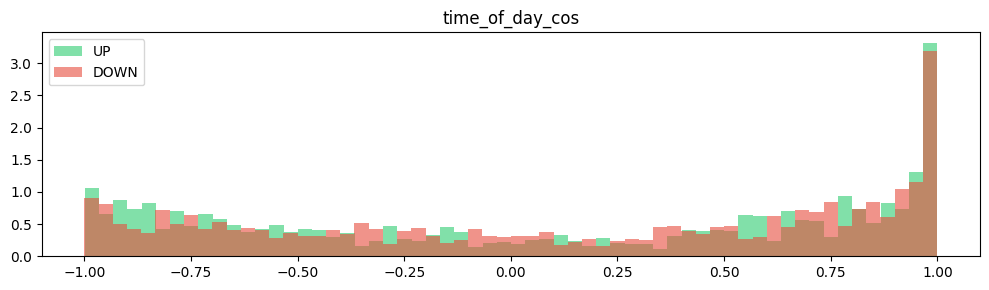

Plotting:  85%|████████▍ | 44/52 [00:06<00:01,  6.75it/s]

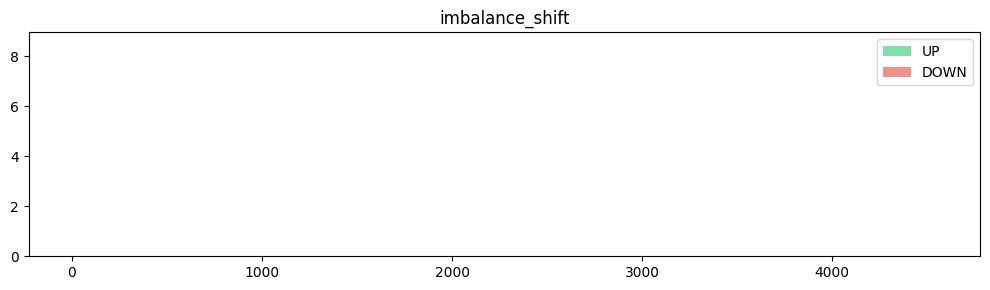

Plotting:  87%|████████▋ | 45/52 [00:06<00:01,  6.69it/s]

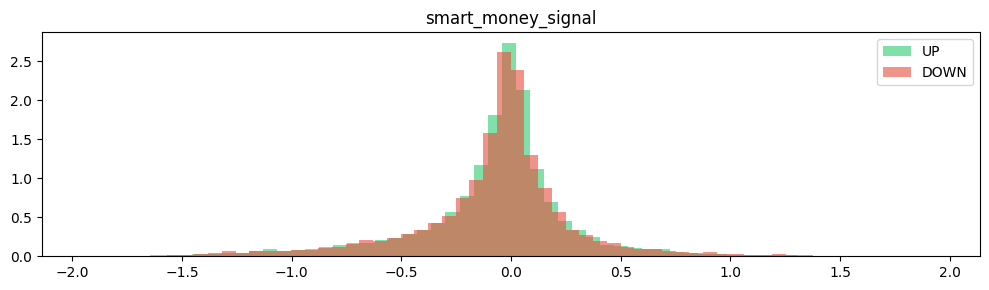

Plotting:  88%|████████▊ | 46/52 [00:06<00:00,  6.65it/s]

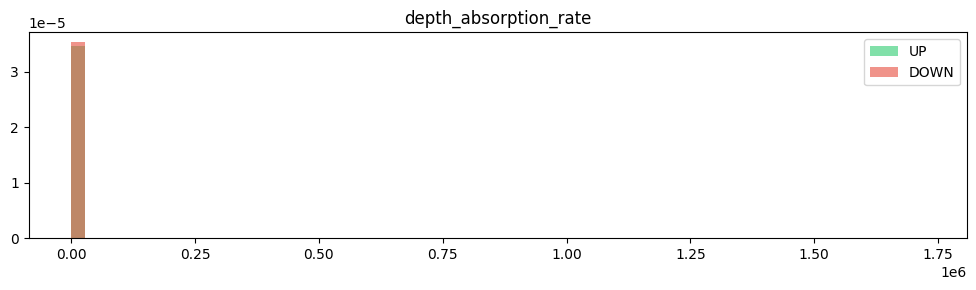

Plotting:  90%|█████████ | 47/52 [00:06<00:00,  5.29it/s]

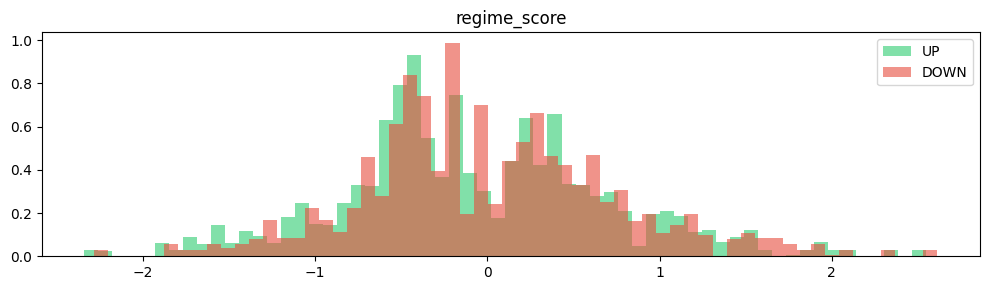

Plotting:  92%|█████████▏| 48/52 [00:06<00:00,  5.60it/s]

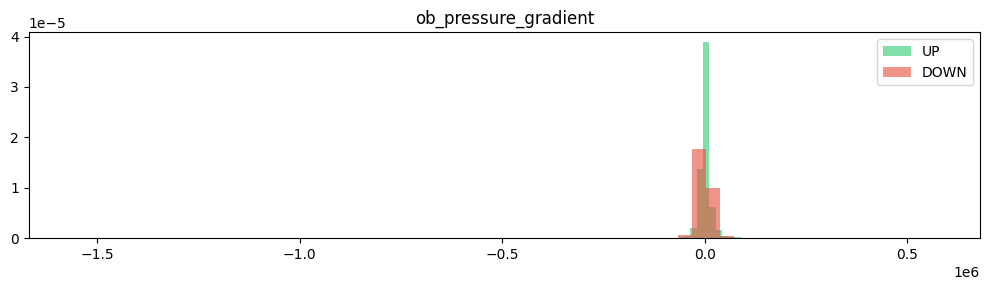

Plotting:  94%|█████████▍| 49/52 [00:07<00:00,  5.78it/s]

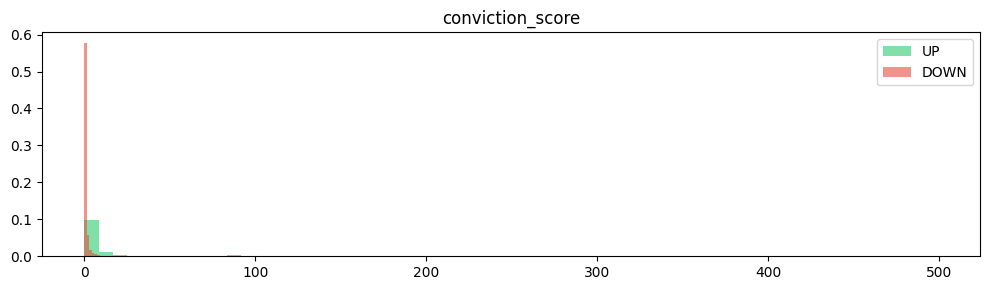

Plotting:  96%|█████████▌| 50/52 [00:07<00:00,  6.12it/s]

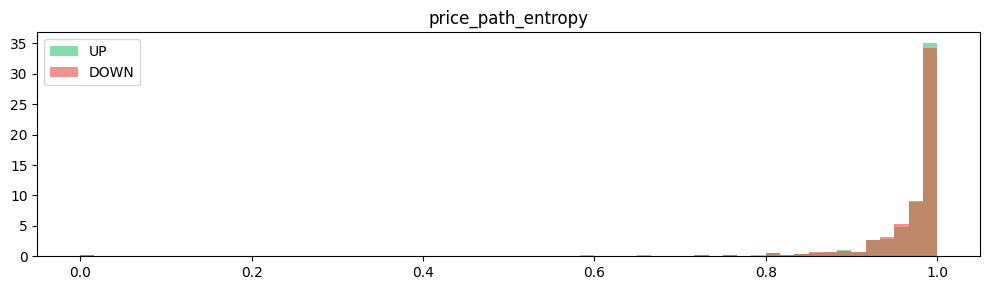

Plotting:  98%|█████████▊| 51/52 [00:07<00:00,  6.39it/s]

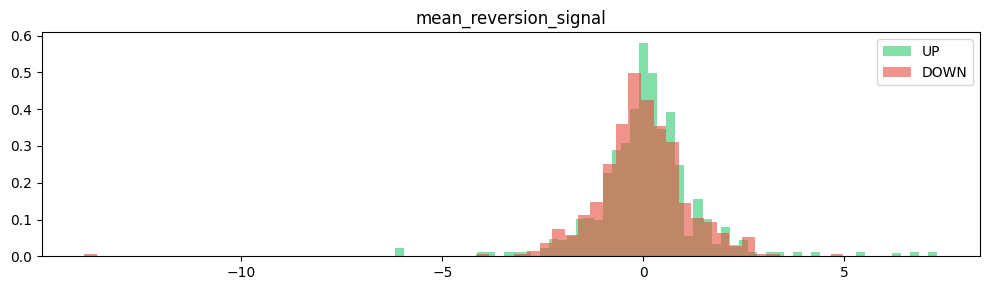

Plotting: 100%|██████████| 52/52 [00:07<00:00,  6.88it/s]


In [22]:
def plot_indicator(name, rows):
    up_vals = [r[name] for r in rows if r[name] is not None and r["outcome"] == "UP"]
    dn_vals = [r[name] for r in rows if r[name] is not None and r["outcome"] == "DOWN"]
    if not up_vals or not dn_vals:
        print(f"Skipping {name} — no data")
        return

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(up_vals, bins=60, alpha=0.6, color="#2ecc71", label="UP", density=True)
    ax.hist(dn_vals, bins=60, alpha=0.6, color="#e74c3c", label="DOWN", density=True)
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()


for key in tqdm(indicator_keys, desc="Plotting"):
    plot_indicator(key, rows)

## 7. Effect size ranking

**What:** Rank all indicators by how well they separate UP from DOWN outcomes, using Cohen's d effect size: `|mean_UP - mean_DOWN| / std_all`.

**Why:** The histograms give a visual sense of separation, but we need a single number to rank indicators objectively. Effect size measures how many standard deviations apart the UP and DOWN means are. It's independent of sample size, so it fairly compares indicators with different coverage levels.

**How to interpret the table:**
- **Effect > 0.1** (strong) = meaningful separation, likely useful as a feature
- **Effect 0.05–0.1** (moderate) = some signal, may help in combination with others
- **Effect < 0.05** (weak) = little to no univariate signal — might still be useful in interaction with other features, but alone it's noise
- **UP mean vs DN mean** = the raw averages. The sign of the difference tells you the *direction*: positive diff means higher values predict UP.

**How to read the bar chart:**
- Indicators are sorted top-to-bottom from most to least predictive
- **Green bars** = effect > 0.1 (strong signal)
- **Orange bars** = effect 0.05–0.1 (moderate)
- **Gray bars** = effect < 0.05 (weak)
- The **dashed green line** at 0.1 marks the threshold for "strong"
- Indicators at the top of the chart are the most promising features for a model; those at the bottom may be candidates for removal to reduce dimensionality

In [23]:
ranked = []
for key in indicator_keys:
    up_v = [r[key] for r in rows if r[key] is not None and r["outcome"] == "UP"]
    dn_v = [r[key] for r in rows if r[key] is not None and r["outcome"] == "DOWN"]
    if not up_v or not dn_v:
        continue
    all_v = up_v + dn_v
    diff = np.mean(up_v) - np.mean(dn_v)
    std = np.std(all_v)
    effect = abs(diff) / std if std > 0 else 0.0
    ranked.append((key, len(all_v), np.mean(up_v), np.mean(dn_v), diff, effect))

ranked.sort(key=lambda x: -x[5])

print(f"{'Indicator':<30} {'N':>8} {'UP mean':>10} {'DN mean':>10} {'Effect':>8}")
print("-" * 70)
for name, n, up_m, dn_m, _diff, effect in ranked:
    print(f"{name:<30} {n:>8,} {up_m:>10.4f} {dn_m:>10.4f} {effect:>8.4f}")

Indicator                             N    UP mean    DN mean   Effect
----------------------------------------------------------------------
down_implied_probability         85,743     0.3435     0.6455   1.0903
up_implied_probability           85,783     0.6562     0.3547   1.0895
btc_move_from_open               94,336    41.5183   -43.6240   0.9439
up_token_velocity                90,703     0.3250    -0.3488   0.8148
down_token_velocity              90,704    -0.3246     0.3493   0.8144
rr_spread                        85,764    -6.1612     6.2355   0.7375
up_spread_level                  94,308     0.0258     0.0563   0.7113
intra_candle_skewness            86,518     0.5094    -0.6402   0.6444
btc_velocity                     92,486    88.5321   -94.7243   0.6051
conviction_score                 88,465     8.0783     0.8018   0.4800
down_risk_reward                 89,944    22.2036     0.9945   0.3237
up_risk_reward                   90,154     0.8781    22.3319   0.3215
weight

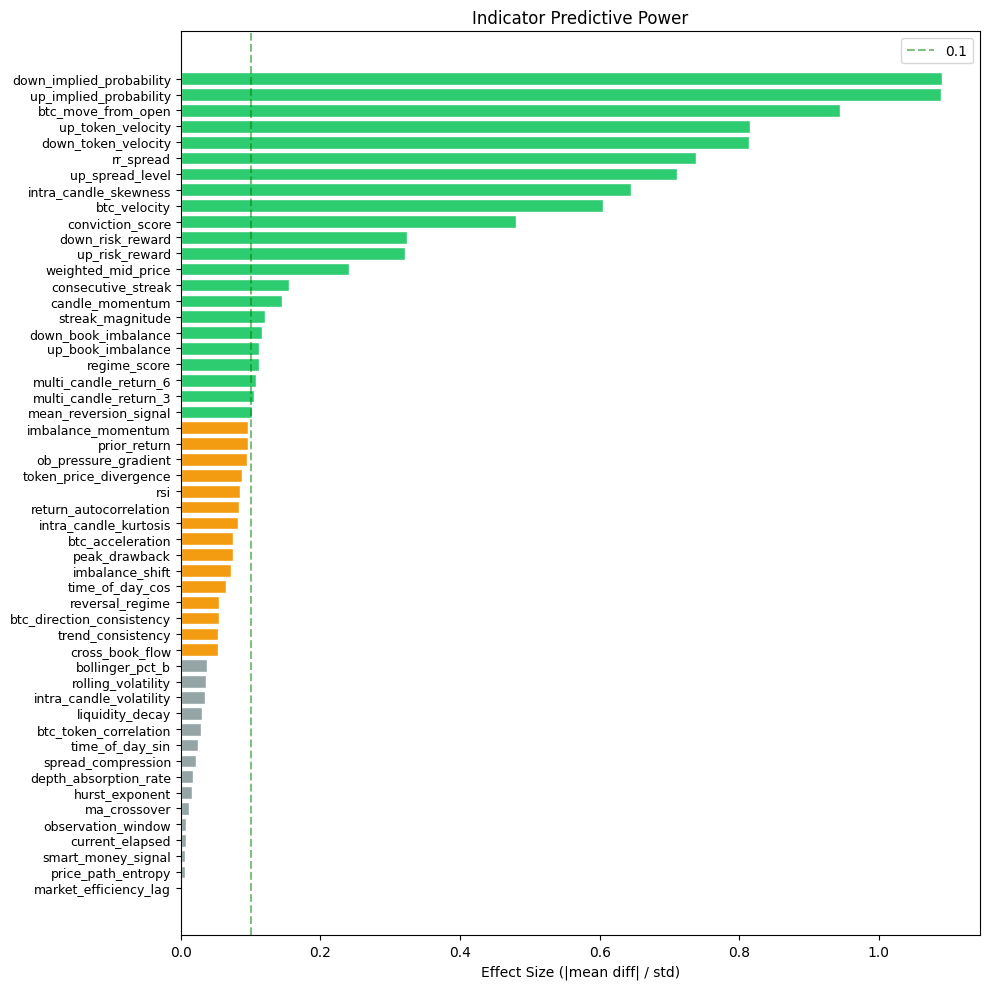

In [25]:
names = [r[0] for r in ranked]
effects = [r[5] for r in ranked]

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#2ecc71" if e > 0.1 else "#f39c12" if e > 0.05 else "#95a5a6" for e in effects]
ax.barh(range(len(names)), effects, color=colors, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("Effect Size (|mean diff| / std)")
ax.set_title("Indicator Predictive Power")
ax.invert_yaxis()
ax.axvline(0.1, color="green", linestyle="--", alpha=0.5, label="0.1")
ax.legend()
plt.tight_layout()
plt.show()